## M504 AI and Applications  
**Project title:** `Brazilian E-Commerce Data Analysis`    
**Student name:** Deepak Sindhu 
**Module:** M504 AI and Applications 
**Student Id:** GH1056312

### 1. Business Context

**Client:** Olist, an online company that connects small businesses with consumers across the country.

**Dataset:** From 2016 to 2018, around one lakh orders were placed and available in this dataset. Order, customer, product, seller, payment, shipping and customer review details are all included.

**Why a data scientist is needed:**  
Olist wants to find out what is important about its revenue and customer satisfaction. This will help the company make better decisions about inventory, managing sellers, shipping and marketing. They need a clear analysis of their past performance.

**Objective of this project:**  
I am working as a data analyst with company and I have to clean, analyse and explore the data, answer important business queries and provide suggestions.

**Data Name:** Brazilian E-Commerce Public Dataset by Olist
**Dataset URL:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

## 2. Dataset Exploration

The dataset is distributed across several related CSV files. The main tables used are orders, customers, order items, products, sellers, payments, reviews and product-category translation.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

customers = pd.read_csv("olist_customers_dataset.csv") 
orders = pd.read_csv("olist_orders_dataset.csv") 
items = pd.read_csv("olist_order_items_dataset.csv") 
products = pd.read_csv("olist_products_dataset.csv") 
sellers = pd.read_csv("olist_sellers_dataset.csv") 
payments = pd.read_csv("olist_order_payments_dataset.csv") 
reviews = pd.read_csv("olist_order_reviews_dataset.csv") 
translation = pd.read_csv("product_category_name_translation.csv") 

print("Orders:", orders.shape) 
print("Customers:", customers.shape) 
print("Items:", items.shape) 
print("Products:", products.shape) 
print("Sellers:", sellers.shape) 
print("Payments:", payments.shape) 
print("Reviews:", reviews.shape)


Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Payments: (103886, 5)
Reviews: (99224, 7)


**Interpretation:** The tables are related to each other rather than independent. Therefore, to join these table, requires correct keys such as order_id, customer_id, product_id and seller_id.

In [2]:
# Checking missing values and duplicates

tables = {
    "customers": customers,
    "orders": orders,
    "items": items,
    "products": products,
    "sellers": sellers,
    "payments": payments,
    "reviews": reviews,
    "translation": translation
}

print("missing values")

for name, table in tables.items():
    missing = table.isna().sum()
    missing = missing[missing > 0]
    print(f"\n {name.upper()} ({table.shape[0]:,} rows × {table.shape[1]} columns)")
    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing.to_string())
        print(f"Total missing cells: {table.isna().sum().sum():,}")

for name, table in tables.items():
    n_duplicates = table.duplicated().sum()
    print(f"{name:12} → {n_duplicates:,} fully duplicate rows")

# duplicate checks on primary and business keys
key_checks = {
    "customers": "customer_id",
    "orders": "order_id",
    "items": ["order_id", "order_item_id"],
    "products": "product_id",
    "sellers": "seller_id",
    "payments": ["order_id", "payment_sequential"],
    "reviews": "review_id",
    "translation": "product_category_name"
}

for name, key in key_checks.items():
    n_dup = tables[name].duplicated(subset=key).sum()
    print(f"{name:12} (key: {key}) → {n_dup:,} duplicate key(s)")

missing values

 CUSTOMERS (99,441 rows × 5 columns)
No missing values

 ORDERS (99,441 rows × 8 columns)
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
Total missing cells: 4,908

 ITEMS (112,650 rows × 7 columns)
No missing values

 PRODUCTS (32,951 rows × 9 columns)
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
Total missing cells: 2,448

 SELLERS (3,095 rows × 4 columns)
No missing values

 PAYMENTS (103,886 rows × 5 columns)
No missing values

 REVIEWS (99,224 rows × 7 columns)
review_comment_title      87656
review_comment_message    58247
Total missing cells: 145,903

 TRANSLATION (71 rows × 2 columns)
No missing values
customers    → 0 fully duplicate rows
orders       → 0 fully duplicate r

**Interpretation:**
The dataset is generally clean. Missing values mainly appear in order delivery timestamps (expected for non-delivered orders) and a small number of product attributes. Almost all tables have unique keys. 814 duplicate review ID are the only quality issue. These should be removed prior to analysis to avoid inflating customer satisfaction metrics.

In [3]:
# removing duplicate reviews

print("Reviews shape before removing duplicates:", reviews.shape)
print("Duplicate review_id count:", reviews.duplicated(subset="review_id").sum())

# Keep only the first instance of each review_id
reviews = reviews.drop_duplicates(subset="review_id", keep="first")

print("Reviews shape after removing duplicates:", reviews.shape)
print("Duplicate review_id count after cleaning:", reviews.duplicated(subset="review_id").sum())

Reviews shape before removing duplicates: (99224, 7)
Duplicate review_id count: 814
Reviews shape after removing duplicates: (98410, 7)
Duplicate review_id count after cleaning: 0


In [4]:
review = reviews[["order_id","review_score"]].drop_duplicates("order_id")

**Interpretation**
Only the initial instance of each review was retained in order to eliminate duplicate review records (814 duplicate review_ids).
This guaranties that every review is only counted once, improving the accuracy and dependability of subsequent customer satisfaction analyzes.

In [5]:
orders.info() 
orders.isna().sum().sort_values(ascending=False).head(10) 
orders["order_status"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

**Interpretation:**
The order table contains various timestamps indicating different phases of the order lifecycle. Missing delivery dates need to be considered carefully because not every order reached the delivered stage 

## 3. Data Preprocessing

First, convert the order dates into datetime format.

In [6]:
date_columns = [ "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date" ] 
for c in date_columns: orders[c] = pd.to_datetime(orders[c], errors="coerce")

The product-category translation is added so that product categories can be interpreted in English.

In [7]:
products = products.merge( translation, on="product_category_name", how="left" )

products["category"] = products["product_category_name_english"].fillna( products["product_category_name"] )

For the main analysis, delivered orders are used for delivery-performance questions because actual delivery time cannot be calculated reliably for orders that were not delivered.

In [8]:
delivered = orders[orders["order_status"]=="delivered"].copy() 
delivered["delivery_days"] = ( delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"] ).dt.total_seconds()/86400 
delivered["delay_days"] = ( delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"] ).dt.total_seconds()/86400 
delivered["late"] = delivered["delay_days"] > 0

In [9]:
# Creating analytical order-item dataset.

df = items.merge( delivered[["order_id","customer_id","order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date","delivery_days","late"]], on="order_id", how="inner" ) 
df = df.merge( customers[["customer_id","customer_state"]], on="customer_id", how="left" ) 
df = df.merge( products[["product_id","category"]], on="product_id", how="left" ) 
df = df.merge( sellers[["seller_id","seller_state"]], on="seller_id", how="left" ) 
df["revenue"] = df["price"] + df["freight_value"] 
df["month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str) 
print(df.shape) 
print(df.isna().sum().sort_values(ascending=False).head())

(110197, 18)
category                         1537
order_delivered_customer_date       8
delivery_days                       8
order_item_id                       0
revenue                             0
dtype: int64


## 4. Explanatory Data Analysis

## Business Question 1  — Which product categories generate the highest revenue? 

**Business importance**
This can support inventory, promotion and category-management decisions.

                          revenue  orders  items
category                                        
health_beauty          1412089.53    8647   9465
watches_gifts          1264333.12    5495   5859
bed_bath_table         1225209.26    9272  10953
sports_leisure         1118256.91    7530   8431
computers_accessories  1032723.77    6530   7644
furniture_decor         880329.92    6307   8160
housewares              758392.25    5743   6795
cool_stuff              691680.89    3559   3718
auto                    669454.75    3810   4140
garden_tools            567145.68    3448   4268


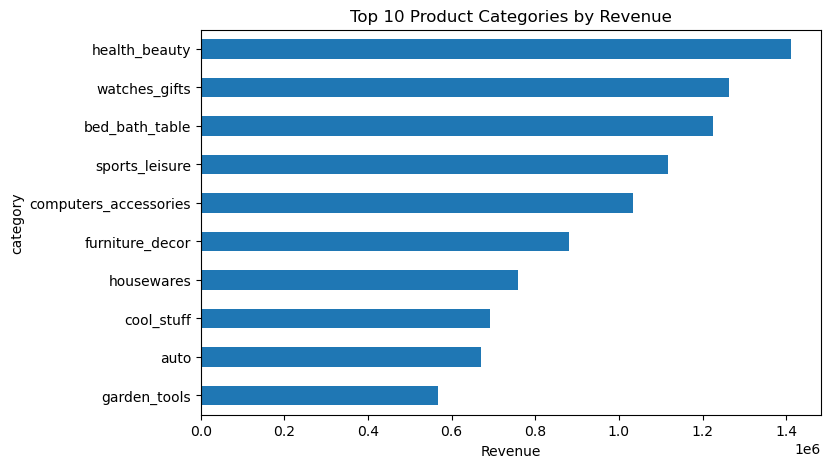

In [10]:
category_sales = ( df.groupby("category") .agg(revenue=("revenue","sum"), orders=("order_id","nunique"), items=("product_id","count")) .sort_values("revenue",ascending=False) .head(10) ) 
print(category_sales) 
category_sales["revenue"].sort_values().plot(kind="barh",figsize=(8,5)) 
plt.title("Top 10 Product Categories by Revenue") 
plt.xlabel("Revenue") 
plt.show()

**Interpretation**
The output identifies the highest-revenue product categories. These categories represent important commercial areas for Olist. However, high revenue is not related to high customer satisfaction, so category performance should also be considered parallel to reviews and delivery performance.

## Business Question 2 — How was revenue changed over time?

**Business importance**
To identify periods of growth, seasonality and potential changes in customer purchasing behaviour, monthly revenue could help management in this.

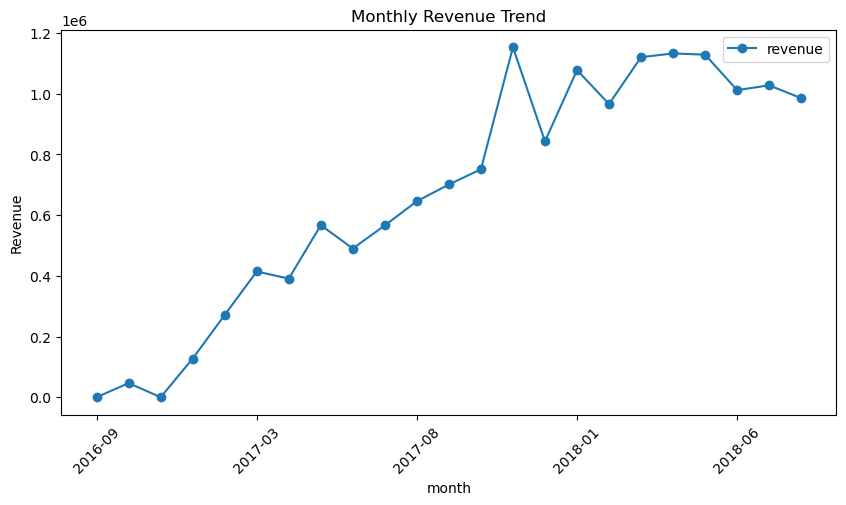

In [11]:
monthly = ( df.groupby("month") .agg(revenue=("revenue","sum"), orders=("order_id","nunique")) .reset_index() ) 
monthly.plot(x="month",y="revenue",figsize=(10,5),marker="o") 
plt.xticks(rotation=45) 
plt.title("Monthly Revenue Trend") 
plt.ylabel("Revenue") 
plt.show()

**Interpretation**
Peaks values indicate stronger purchasing periods, while weaker months may require promotional or marketing attention. The observed pattern cannont be treated as permanent pattern or future rule, it is just for the time period of the data we have.

## Business Question 3 — Which states generate the most revenue?

**Business importance**
Geographic analysis helps the business to find its strongest markets and see where most of sales  is happenning.

                   revenue  orders
customer_state                    
SP              5769703.15   40501
RJ              2055401.57   12350
MG              1818891.67   11354
RS               861472.79    5345
PR               781708.80    4923
SC               595127.78    3546
BA               591137.81    3256
DF               346123.35    2080
GO               334212.35    1957
ES               317657.93    1995


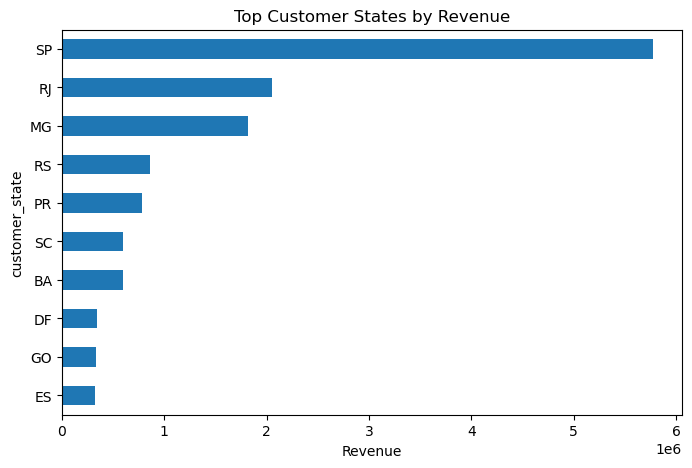

In [12]:
state_sales_data = ( df.groupby("customer_state") .agg(revenue=("revenue","sum"), orders=("order_id","nunique")) .sort_values("revenue",ascending=False) .head(10) ) 
print(state_sales_data) 
state_sales_data["revenue"].sort_values().plot( kind="barh",figsize=(8,5) ) 
plt.title("Top Customer States by Revenue") 
plt.xlabel("Revenue") 
plt.show()

**Interpretation**
The results shows the states contributes more in generating revenue. The result suggests that Olist may have opportunities to expand sales in lower-performing areas, while strong markets could receive targeted retention and promotional activity.

## Business Question 4 — Does delivery performance affect customer satisfaction?

**Business importance**
Due to Late delivery, the customer can effect negatively. Understanding the relationship between delivery performance and reviews, management can improve logistics services.

       count      mean
late                  
False  87759  4.296175
True    7613  2.565874


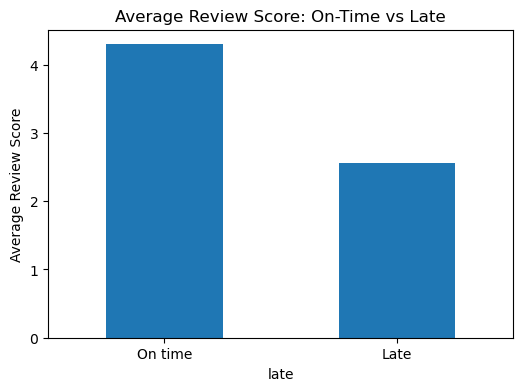

In [13]:
review = reviews[["order_id","review_score"]].drop_duplicates("order_id") 
delivery_review = delivered[ ["order_id","delivery_days","late"] ].merge(review,on="order_id",how="inner") 
print( delivery_review.groupby("late")["review_score"] .agg(["count","mean"]) ) 
delivery_review.groupby("late")["review_score"].mean().plot( kind="bar",figsize=(6,4) ) 
plt.title("Average Review Score: On-Time vs Late") 
plt.ylabel("Average Review Score") 
plt.xticks([0,1],["On time","Late"],rotation=0) 
plt.show()

**Interpretation**
The comparison shows whether customers who experienced late delivery gave lower average review scores. If late orders have a substantially lower score, delivery reliability should be treated as an important customer-experience priority.

This does not prove that late delivery is the only cause of customer dissatifaction because other factors, such as product quality and seller performance,  also influence reviews.

### Business Question 5 — Which sellers combine high revenue with strong customer satisfaction?

**Business importance**
Seller performance is important because Olist operates as a marketplace. Identifying sellers that generate substantial revenue while maintaining good customer ratings can help management understand successful marketplace behaviour.

In [14]:
seller_rev = ( df.groupby("seller_id") .agg(revenue=("revenue","sum"), orders=("order_id","nunique")) ) 
seller_review = ( df[["order_id","seller_id"]] .merge(review,on="order_id",how="inner") .groupby("seller_id")["review_score"] .mean() ) 
seller_perf = seller_rev.join(seller_review,how="inner") 
top_sellers = seller_perf[ (seller_perf["orders"]>=20) & (seller_perf["review_score"]>=4) ].sort_values("revenue",ascending=False).head(10) 
print(top_sellers)

                                    revenue  orders  review_score
seller_id                                                        
4869f7a5dfa277a7dca6462dcf3b52b2  247007.06    1124      4.137961
53243585a1d6dc2643021fd1853d8905  230797.02     348      4.128141
fa1c13f2614d7b5c4749cbc52fecda94  200833.50     578      4.373913
da8622b14eb17ae2831f4ac5b9dab84a  184706.78    1311      4.075148
7e93a43ef30c4f03f38b393420bc753a  171973.55     319      4.364486
7a67c85e85bb2ce8582c35f2203ad736  160278.52    1145      4.269398
955fee9216a65b617aa5c0531780ce60  156606.48    1261      4.087611
46dc3b2cc0980fb8ec44634e21d2718e  134162.88     503      4.263566
a1043bafd471dff536d0c462352beb48  130412.74     702      4.246667
620c87c171fb2a6dd6e8bb4dec959fc6  126278.18     722      4.264126


**Interpretation**
The filter reduces the influence of sellers with very few orders. Sellers satisfying both conditions generate meaningful revenue and maintain strong average review scores. These sellers can provide useful examples of effective marketplace performance.

### Business Question 6 — Which payment method is most commonly used?

**Business importance**
Payment behaviour can influence checkout design and customer convenience. Understanding the dominant payment methods can help the business prioritise payment options.

              orders        value
payment_type                     
credit_card    76505  12542084.19
boleto         19784   2869361.27
voucher         3866    379436.87
debit_card      1528    217989.79
not_defined        3         0.00


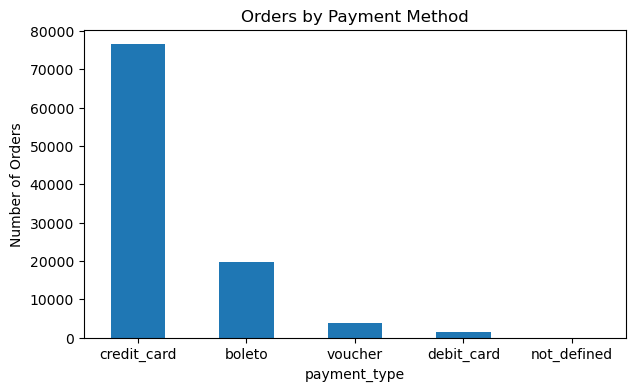

In [15]:
payment_summary = ( payments.groupby("payment_type") .agg( orders=("order_id","nunique"), value=("payment_value","sum") ) .sort_values("value",ascending=False) ) 
print(payment_summary) 
payment_summary["orders"].plot( kind="bar",figsize=(7,4) ) 
plt.title("Orders by Payment Method") 
plt.ylabel("Number of Orders") 
plt.xticks(rotation=0) 
plt.show()

**Interpretation**
The results shows that the payment methods most frequently used by customers and the total payment value associated with each method. The business can use this information to make sure that popular payment options is always reliable and easy to use.

### Business Question 7 —Which product categories are associated with the lowest customer review scores?

**Business importance**
Revenue alone does not provide a complete picture of product performance. Categories with poor customer satisfaction may require investigation into product quality, seller behaviour, descriptions or delivery.

In [16]:
# Creating unique order-category combination
category_review = (
    df[["order_id", "category"]]
    .drop_duplicates()
    .merge(
        review,
        on="order_id",
        how="inner"
    )
)

# calculating review score through category
cat_review = (
    category_review
    .groupby("category")
    .agg(
        reviews=("review_score", "count"),
        score=("review_score", "mean")
    )
    .sort_values("score")
)

cat_review


,reviews,score
category,,
security_and_services,2,2.500000
pc_gamer,7,3.428571
portateis_cozinha_e_preparadores_de_alimentos,13,3.615385
office_furniture,1237,3.644301
fashion_male_clothing,104,3.817308
...,...,...
books_imported,50,4.440000
food_drink,218,4.444954
books_general_interest,492,4.534553


**Interpretation**
The result only check at categories that have a minimum number of reviews. This helps avoid drawing results from groups that have so much less reviews. Even with this rule, some categories still show lower average scores than others

In [17]:
cat_review_filtered = cat_review[cat_review["reviews"] >= 50]

print(cat_review_filtered.head(10))

                           reviews     score
category                                    
office_furniture              1237  3.644301
fashion_male_clothing          104  3.817308
audio                          345  3.840580
home_confort                   389  3.902314
fixed_telephony                209  3.966507
construction_tools_safety      158  3.974684
home_construction              478  3.985356
fashion_underwear_beach        114  3.991228
bed_bath_table                9078  4.003966
telephony                     4064  4.052165


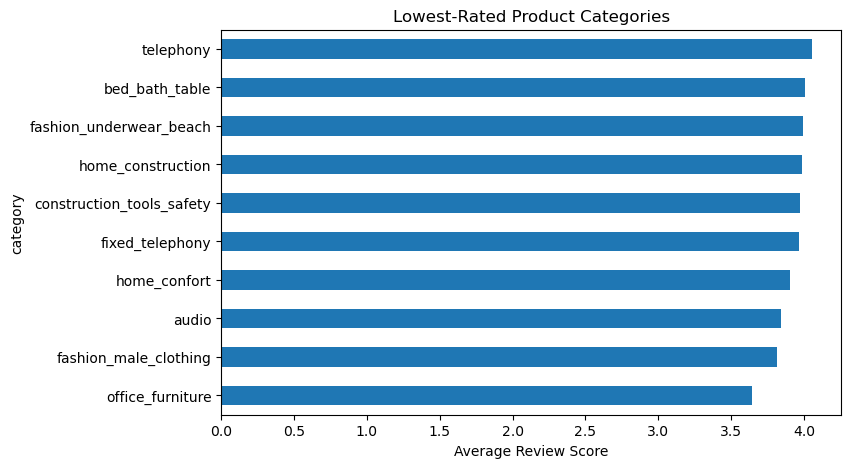

In [18]:
cat_review_filtered.head(10)["score"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Lowest-Rated Product Categories")
plt.xlabel("Average Review Score")
plt.show()

**Interpretation**
Based only on products with at least 50 reviews, Office furniture  get lower ratings than other categories
These are just patterns in the data, they do not prove why the scores are lower. More research is required to understand the cause.

### Business Question 8 — Are expensive freight costs associated with lower customer satisfaction?

**Business importance**
Freight is a significant part of the customer purchase experience. High shipping costs may affect perceived value and customer satisfaction.

In [19]:
freight_review = ( df[["order_id","freight_value"]] .merge(review,on="order_id",how="inner") ) 
freight_bins = pd.qcut( freight_review["freight_value"], q=4, duplicates="drop" ) 
print( freight_review.groupby(freight_bins,observed=True)["review_score"] .mean() )

freight_value
(-0.001, 13.07]    4.166409
(13.07, 16.26]     4.107998
(16.26, 21.15]     4.064593
(21.15, 409.68]    3.997044
Name: review_score, dtype: float64


**Interpretation**
The quartile analysis compares customer satisfaction between different groups of freight costs. If average review scores decline as freight costs increase, shipping cost could be an important factor in customer experience. However, freight cost can also depend on the size, weight and destination of the product, so it should not be automatically assumed that there is a causal relationship.

## 5. Overall Findings

The analysis demonstrates how Olist's relational data can be combined to investigate sales, customers, products, sellers, payments and logistics.

The strongest business insights should be taken from the actual outputs generated by the notebook. Particular attention should be given to:

highest-revenue product categories;
monthly revenue patterns;
strongest customer states;
delivery performance and review scores;
high-performing sellers;
dominant payment methods;
low-rated product categories;
relationship between freight cost and customer satisfaction.

The analysis also demonstrates that business performance cannot be evaluated using revenue alone. Customer satisfaction and logistics performance provide additional dimensions for evaluating marketplace performance.

## 6. Business Recommendations
**Focus on categories that are doing well**
The company should continue to provide its products in categories that generate a good amount of revenue and run focused promotions.

**Enhance delivery reliability**

If the analysis justifies lower review scores for late delivery, then logistics performance should be prioritized. The company should monitor late delivery rates by seller and location.

**Look out for low-rated categories**
In categories where review scores remain low, product quality, seller performance, descriptions and delivery issues should all be investigated.

**Give rewards to successful sellers**
High-revenue vendors with high customer ratings could be benchmarked against marketplace best practices.

**Keep popular payment methods prominent**
At checkout, popular payment options should still be front and center and trustworthy.

**Check out regional opportunities**
Potential expansion opportunities would be areas with lower revenue but marketing investment should be supported by further analysis of the customer, logistics and purchasing behavior.

## 7. Limitations

This analysis has several limitations.

First, the dataset covers a historical period from 2016 to 2018, so the findings should not automatically be generalised to the current e-commerce market.

Second, the analysis is explanatory rather than causal. Relationships between delivery, freight, reviews and sales do not prove that one variable directly causes another.

Third, some orders do not have complete delivery information. Therefore, delivery-time analysis focuses on delivered orders.

Finally, customer reviews are subjective and may not capture every aspect of customer experience.

## 8. Conclusion

In this research, the Olist Brazilian e-commerce dataset was analyzed in an explanatory way using Python and Pandas . An analytical dataset was created by cleaning and merging several relevant datasets.

The eight business questions studied were in the areas of sales, time, location, logistics, sellers, payments, product categories and customer happiness.

The analysis shows how data-driven techniques can turn transactional data into business insights. The most important managerial insight is that market performance should be judged by multiple measures, not revenue alone. The sales data, combined with consumer input, delivery performance and seller behavior provides a more complete picture of the business.

## References

Olist (n.d.) Brazilian E-Commerce Public Dataset by Olist. Kaggle. Available at: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

Kaggle (n.d.) Brazilian E-Commerce Public Dataset by Olist — Data Card and Schema. Available at: https://www.kaggle.com/olistbr/brazilian-ecommerce